<div style="border-top:8px solid #EB0A1E; padding:28px 24px 20px; background:linear-gradient(135deg,#ffffff 0%,#f6f7f9 100%); border-radius:8px;">
  <div style="display:flex;align-items:center;gap:26px;">
   <img src="toyota_logo.png" alt="Toyota logo" width="150">
      <h1 style="margin:0;color:#222;font-size:38px;">Toyota Car Sales Analysis</h1>
      <p style="margin:7px 0 0;color:#EB0A1E;font-size:19px;"><b>An end-to-end SQL and Python analytics case study</b></p>
    </div>
  </div>
  <hr style="border:0;border-top:1px solid #ddd;margin:22px 0;">
  <p style="font-size:16px;line-height:1.6;">This portfolio project analyses a synthetic Toyota car-sales database to evaluate sales performance, identify trends, measure business KPIs, and generate actionable evidence-based insights.</p>
  <table style="font-size:15px;line-height:1.7;">
    <tr><td><b>Objective</b></td><td>Analyse transactions, customers, models, dealerships, regions, inventory, employees, and after-sales service.</td></tr>
    <tr><td><b>Tools</b></td><td>MySQL · SQLAlchemy · PyMySQL · pandas · NumPy · Matplotlib · Seaborn · Plotly</td></tr>
    <tr><td><b>Author</b></td><td>Hitesh Sharma</td></tr>
  </table>
</div>

> **Portfolio disclosure:** The source dump identifies this as synthetic educational data and states that it is not affiliated with Toyota Motor Corporation. The Toyota mark is displayed only for project identification; all monetary measures in the source are denominated in **USD**.


## Project Scope and Data Model

The supplied MySQL dump contains eight related tables. The analytical grain is one row per record in `sales`; descriptive attributes are joined through documented foreign keys.

| Table | Role | Available columns |
|---|---|---|
| `sales` | Transaction fact | `sale_id`, `sale_date`, `customer_id`, `model_id`, `dealership_id`, `employee_id`, `quantity`, `unit_price_usd`, `discount_pct`, `payment_method` |
| `customers` | Customer dimension | `customer_id`, `customer_name`, `customer_type`, `region_id`, `join_year` |
| `models` | Vehicle dimension | `model_id`, `model_name`, `vehicle_type`, `fuel_type`, `base_price_usd` |
| `dealerships` | Location dimension | `dealership_id`, `region_id`, `dealership_name`, `city`, `opened_year` |
| `regions` | Region dimension | `region_id`, `region_name`, `currency_code` |
| `employees` | Employee dimension | `employee_id`, `dealership_id`, `employee_name`, `job_title`, `hire_year` |
| `inventory` | Inventory fact | `inventory_id`, `dealership_id`, `model_id`, `received_date`, `units_available`, `inventory_status`, `cost_per_unit_usd` |
| `service_records` | After-sales fact | `service_id`, `sale_id`, `service_date`, `service_type`, `service_cost_usd`, `satisfaction_score`, `service_status` |

**Documented revenue rule:** `quantity × unit_price_usd × (1 − discount_pct / 100)`.

**Unavailable analyses:** the schema has no transmission, salesperson commission, product cost per sale, profit, marketing campaign, customer age/gender, vehicle manufacture year, or competitor fields. Consequently, transmission preference, transaction-level profit/margin, campaign attribution, demographic segmentation, vehicle age, and competitor comparisons are not calculated. Inventory cost is kept separate and is not treated as cost of goods sold.


## Phase 1 – Import Required Libraries

Only libraries used later in the notebook are imported. The visual language follows Toyota red with neutral greys.


In [2]:
import os
import re
import warnings
from getpass import getpass
from urllib.parse import quote_plus

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from IPython.display import Markdown, display
from sqlalchemy import create_engine, inspect, text
from sqlalchemy.exc import SQLAlchemyError

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

TOYOTA_RED = "#EB0A1E"
CHARCOAL = "#2B2B2B"
LIGHT_GREY = "#E8E8E8"
PALETTE = [TOYOTA_RED, "#58595B", "#A7A9AC", "#7A0012", "#D1D3D4"]

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (12, 6), "axes.titleweight": "bold"})
px.defaults.template = "plotly_white"
px.defaults.color_discrete_sequence = PALETTE

RANDOM_STATE = 42


## Phase 2 – Load Data from SQL Database

Credentials are read from environment variables and the password is requested securely only when absent. No password is stored or printed. Before publishing, set `TOYOTA_DB_USER`, `TOYOTA_DB_HOST`, `TOYOTA_DB_PORT`, `TOYOTA_DB_NAME`, and optionally `TOYOTA_DB_PASSWORD` in your local environment.

> Run `01_create_schema.sql` and `02_load_data.sql` in MySQL before executing this notebook. The notebook uses read-only `SELECT` statements and closes the connection after loading.


In [4]:
database_user = os.getenv("TOYOTA_DB_USER", "root")
database_host = os.getenv("TOYOTA_DB_HOST", "localhost")
database_port = os.getenv("TOYOTA_DB_PORT", "3306")
database_name = os.getenv("TOYOTA_DB_NAME", "toyota_car_sales_analysis")
database_password = os.getenv("TOYOTA_DB_PASSWORD") or getpass(
    "MySQL password (input hidden): "
)

connection_url = (
    f"mysql+pymysql://{quote_plus(database_user)}:"
    f"{quote_plus(database_password)}@{database_host}:"
    f"{database_port}/{database_name}"
)

try:
    engine = create_engine(connection_url, pool_pre_ping=True)
    with engine.connect() as connection:
        connection.execute(text("SELECT 1"))
    print(f"Connected successfully to MySQL database: {database_name}")
except SQLAlchemyError as error:
    raise ConnectionError(
        "MySQL connection failed. Confirm that MySQL is running, the dump is "
        "loaded, and the environment variables/credentials are correct."
    ) from error


MySQL password (input hidden):  ········


Connected successfully to MySQL database: toyota_car_sales_analysis


In [5]:
required_tables = [
    "customers",
    "dealerships",
    "employees",
    "inventory",
    "models",
    "regions",
    "sales",
    "service_records",
]

available_tables = set(inspect(engine).get_table_names())
missing_tables = sorted(set(required_tables) - available_tables)
if missing_tables:
    raise ValueError(f"Required tables are missing: {missing_tables}")

tables = {}
try:
    with engine.connect() as connection:
        for table_name in required_tables:
            tables[table_name] = pd.read_sql(
                text(f"SELECT * FROM `{table_name}`"), connection
            )
finally:
    engine.dispose()

print("All required tables loaded successfully.\n")
table_shapes = pd.DataFrame(
    [
        {"table": name, "rows": frame.shape[0], "columns": frame.shape[1]}
        for name, frame in tables.items()
    ]
).sort_values("table")
display(table_shapes.style.format({"rows": "{:,}", "columns": "{:,}"}))


All required tables loaded successfully.



,table,rows,columns
0,customers,"8,000",5
1,dealerships,120,5
2,employees,600,5
3,inventory,"4,262",7
4,models,12,5
5,regions,6,3
6,sales,"40,000",10
7,service_records,"7,000",7


## Phase 3 – Data Understanding

Inspection is performed table by table without printing high-cardinality value lists.


### 3.1–3.4 Dataset shape, row/column counts, column names, and data types


In [6]:
for table_name, frame in tables.items():
    print(f"\n{table_name.upper()} — shape: {frame.shape}")
    print(f"Rows: {frame.shape[0]:,} | Columns: {frame.shape[1]}")
    print("Columns:", frame.columns.tolist())
    display(frame.dtypes.rename("data_type").to_frame())



CUSTOMERS — shape: (8000, 5)
Rows: 8,000 | Columns: 5
Columns: ['customer_id', 'customer_name', 'customer_type', 'region_id', 'join_year']


,data_type
customer_id,int64
customer_name,str
customer_type,str
region_id,int64
join_year,int64



DEALERSHIPS — shape: (120, 5)
Rows: 120 | Columns: 5
Columns: ['dealership_id', 'region_id', 'dealership_name', 'city', 'opened_year']


,data_type
dealership_id,int64
region_id,int64
dealership_name,str
city,str
opened_year,int64



EMPLOYEES — shape: (600, 5)
Rows: 600 | Columns: 5
Columns: ['employee_id', 'dealership_id', 'employee_name', 'job_title', 'hire_year']


...

,data_type
region_id,int64
region_name,str
currency_code,str



SALES — shape: (40000, 10)
Rows: 40,000 | Columns: 10
Columns: ['sale_id', 'sale_date', 'customer_id', 'model_id', 'dealership_id', 'employee_id', 'quantity', 'unit_price_usd', 'discount_pct', 'payment_method']


,data_type
sale_id,int64
sale_date,object
customer_id,int64
model_id,int64
dealership_id,int64
employee_id,int64
quantity,int64
unit_price_usd,float64
discount_pct,float64
payment_method,str



SERVICE_RECORDS — shape: (7000, 7)
Rows: 7,000 | Columns: 7
Columns: ['service_id', 'sale_id', 'service_date', 'service_type', 'service_cost_usd', 'satisfaction_score', 'service_status']


,data_type
service_id,int64
sale_id,int64
service_date,object
service_type,str
service_cost_usd,float64
satisfaction_score,int64
service_status,str


### 3.5–3.7 First, last, and reproducible random records

The transaction table is used for concise record-level inspection.


In [7]:
display(sales_head := tables["sales"].head())
display(sales_tail := tables["sales"].tail())
display(tables["sales"].sample(n=5, random_state=RANDOM_STATE))


,sale_id,sale_date,customer_id,model_id,dealership_id,employee_id,quantity,unit_price_usd,discount_pct,payment_method
0,1,2022-07-04,5181,12,71,351,3,"44,785.00",4.40,Loan
1,2,2021-12-30,4636,8,103,513,1,"57,842.00",7.50,Cash
2,3,2023-07-22,5911,6,26,128,2,"55,965.00",5.21,Loan
3,4,2025-01-21,3713,7,33,165,3,"39,647.00",1.48,Loan
4,5,2022-01-08,1585,7,65,324,1,"40,317.00",7.00,Cash


,sale_id,sale_date,customer_id,model_id,dealership_id,employee_id,quantity,unit_price_usd,discount_pct,payment_method
39995,39996,2023-08-05,5166,8,93,461,3,"57,278.00",11.51,Lease
39996,39997,2025-04-24,585,10,30,147,1,"34,298.00",11.50,Loan
39997,39998,2025-05-19,4435,8,74,367,3,"58,321.00",0.47,Cash
39998,39999,2023-12-26,3734,5,27,133,3,"48,774.00",7.35,Loan
39999,40000,2021-05-23,6070,3,50,250,1,"34,473.00",5.56,Loan


,sale_id,sale_date,customer_id,model_id,dealership_id,employee_id,quantity,unit_price_usd,discount_pct,payment_method
32823,32824,2021-07-07,967,5,25,122,3,"47,748.00",2.38,Cash
16298,16299,2021-07-17,7528,1,112,556,1,"23,582.00",11.64,Loan
28505,28506,2021-03-06,6914,7,115,572,3,"44,395.00",7.13,Lease
6689,6690,2022-10-27,792,8,4,18,2,"57,137.00",9.81,Loan
26893,26894,2023-10-24,1510,9,82,409,3,"48,191.00",8.24,Cash


### 3.8 Dataset information


In [8]:
for table_name, frame in tables.items():
    print(f"\n--- {table_name.upper()} ---")
    frame.info(memory_usage="deep")



--- CUSTOMERS ---
<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customer_id    8000 non-null   int64
 1   customer_name  8000 non-null   str  
 2   customer_type  8000 non-null   str  
 3   region_id      8000 non-null   int64
 4   join_year      8000 non-null   int64
dtypes: int64(3), str(2)
memory usage: 1.1 MB

--- DEALERSHIPS ---
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   dealership_id    120 non-null    int64
 1   region_id        120 non-null    int64
 2   dealership_name  120 non-null    str  
 3   city             120 non-null    str  
 4   opened_year      120 non-null    int64
dtypes: int64(3), str(2)
memory usage: 17.2 KB

--- EMPLOYEES ---
<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 5

### 3.9–3.10 Numerical and categorical statistical summaries


In [9]:
display(tables["sales"].describe().T)
categorical_summary = tables["sales"].describe(
    include=["object", "string", "category"]
).T
display(categorical_summary)


,count,mean,std,min,25%,50%,75%,max
sale_id,"40,000.00","20,000.50","11,547.15",1.00,"10,000.75","20,000.50","30,000.25","40,000.00"
customer_id,"40,000.00","4,008.10","2,318.05",1.00,"1,982.00","4,013.50","6,030.00","8,000.00"
model_id,"40,000.00",6.52,3.45,1.00,4.00,7.00,10.00,12.00
dealership_id,"40,000.00",60.34,34.68,1.00,30.00,61.00,90.00,120.00
employee_id,"40,000.00",299.69,173.42,1.00,149.00,301.00,450.00,600.00
quantity,"40,000.00",2.00,0.82,1.00,1.00,2.00,3.00,3.00
unit_price_usd,"40,000.00","42,360.33","10,605.35","22,786.00","33,095.75","43,315.50","50,149.00","63,129.00"
discount_pct,"40,000.00",6.24,3.61,0.00,3.12,6.26,9.36,12.50


,count,unique,top,freq
sale_date,40000,1826,2021-10-01,38
payment_method,40000,3,Cash,13467


### 3.11 Missing values

The function reports only affected columns; an empty result indicates complete fields.


In [10]:
def missing_value_summary(frame):
    missing_count = frame.isna().sum()
    summary = pd.DataFrame(
        {
            "missing_count": missing_count,
            "missing_pct": missing_count.div(len(frame)).mul(100),
        }
    )
    return summary.loc[summary["missing_count"].gt(0)]


for table_name, frame in tables.items():
    summary = missing_value_summary(frame)
    print(f"{table_name}: {summary.shape[0]} columns with missing values")
    if not summary.empty:
        display(summary)


customers: 0 columns with missing values
dealerships: 0 columns with missing values
employees: 0 columns with missing values
inventory: 0 columns with missing values
models: 0 columns with missing values
regions: 0 columns with missing values
sales: 0 columns with missing values
service_records: 0 columns with missing values


### 3.12–3.14 Duplicate rows, cardinality, and memory usage


In [11]:
quality_profile = []
for table_name, frame in tables.items():
    quality_profile.append(
        {
            "table": table_name,
            "duplicate_rows": int(frame.duplicated().sum()),
            "memory_mb": frame.memory_usage(deep=True).sum() / 1024**2,
        }
    )
display(pd.DataFrame(quality_profile).style.format({"memory_mb": "{:.3f}"}))

unique_counts = pd.concat(
    {name: frame.nunique(dropna=False) for name, frame in tables.items()},
    names=["table", "column"],
).rename("unique_values").to_frame()
display(unique_counts)


,table,duplicate_rows,memory_mb
0,customers,0,1.089
1,dealerships,0,0.017
2,employees,0,0.086
3,inventory,0,0.553
4,models,0,0.002
5,regions,0,0.001
6,sales,0,6.002
7,service_records,0,1.271


unique_values
table           column                           
customers       customer_id                  8000
                customer_name                 120
                customer_type                   3
                region_id                       6
                join_year                       7
dealerships     dealership_id                 120
                region_id                       6
                dealership_name               120
                city                           15
                opened_year                    15
employees       employee_id                   600
                dealership_id                 120
                employee_name                 119
                job_title                       3
                hire_year                      10
inventory       inventory_id                 4262
                dealership_id                 120
                model_id                       12
                received_date                1657
                units_available                18
                inventory_status                3
                cost_per_unit_usd            3839
models          model_id                       12
                model_name                     12
                vehicle_type                    7
                fuel_type                       3
                base_price_usd                 12
regions         region_id                       6
                region_name                     6
                currency_code                   6
sales           sale_id                     40000
                sale_date                    1826
                customer_id                  7943
                model_id                       12
                dealership_id                 120
                employee_id                   600
                quantity                        3
                unit_price_usd              22985
                discount_pct                 1251
                payment_method                  3
service_records service_id                   7000
                sale_id                      6396
                service_date                 1920
                service_type                    4
                service_cost_usd             1403
                satisfaction_score             10
                service_status                  2

## Phase 4 – Data Cleaning

The SQL schema already enforces primary keys, foreign keys, non-null constraints, unsigned quantities, and decimal monetary types. Cleaning therefore focuses on validation and safe normalisation—not arbitrary imputation or blanket outlier deletion.


### 4.1 Working copies and standardised column names


In [12]:
def standardise_column_name(column):
    cleaned = re.sub(r"[^a-zA-Z0-9]+", "_", column.strip().lower())
    return cleaned.strip("_")


cleaned_tables = {name: frame.copy() for name, frame in tables.items()}
for frame in cleaned_tables.values():
    frame.columns = [standardise_column_name(column) for column in frame.columns]

before_shapes = {name: frame.shape for name, frame in tables.items()}


### 4.2–4.7 Missing values, duplicates, types, and text consistency


In [13]:
date_columns = {
    "sales": ["sale_date"],
    "inventory": ["received_date"],
    "service_records": ["service_date"],
}

for table_name, columns in date_columns.items():
    for column in columns:
        cleaned_tables[table_name][column] = pd.to_datetime(
            cleaned_tables[table_name][column], errors="raise"
        )

for table_name, frame in cleaned_tables.items():
    text_columns = frame.select_dtypes(include=["object", "string"]).columns
    for column in text_columns:
        frame[column] = (
            frame[column]
            .astype("string")
            .str.strip()
            .str.replace(r"\s+", " ", regex=True)
        )

    primary_key = {
        "customers": "customer_id",
        "dealerships": "dealership_id",
        "employees": "employee_id",
        "inventory": "inventory_id",
        "models": "model_id",
        "regions": "region_id",
        "sales": "sale_id",
        "service_records": "service_id",
    }[table_name]
    if frame[primary_key].duplicated().any():
        raise ValueError(f"Duplicate primary keys detected in {table_name}")

    before = len(frame)
    cleaned_tables[table_name] = frame.drop_duplicates().reset_index(drop=True)
    print(f"{table_name}: {before:,} → {len(cleaned_tables[table_name]):,} rows")


customers: 8,000 → 8,000 rows
dealerships: 120 → 120 rows
employees: 600 → 600 rows
inventory: 4,262 → 4,262 rows
models: 12 → 12 rows
regions: 6 → 6 rows
sales: 40,000 → 40,000 rows
service_records: 7,000 → 7,000 rows


### 4.6 Category consistency audit

Distinct values are shown only for genuinely low-cardinality text columns. No spelling replacement is made unless duplicate labels differ only by case or whitespace.


In [14]:
for table_name, frame in cleaned_tables.items():
    for column in frame.select_dtypes(include=["object", "string"]).columns:
        if frame[column].nunique(dropna=False) <= 15:
            values = sorted(frame[column].dropna().astype(str).unique())
            print(f"{table_name}.{column}: {values}")


customers.customer_type: ['Corporate', 'Government', 'Individual']
dealerships.city: ['Berlin', 'Cairo', 'Cape Town', 'Chicago', 'Dallas', 'Dubai', 'London', 'Mexico City', 'Mumbai', 'Paris', 'Riyadh', 'Sao Paulo', 'Sydney', 'Tokyo', 'Toronto']
employees.job_title: ['Fleet Specialist', 'Sales Executive', 'Senior Sales Executive']
inventory.inventory_status: ['In Stock', 'Reserved', 'Sold']
models.model_name: ['4Runner', 'Camry', 'Corolla', 'GR86', 'Highlander', 'Prius', 'RAV4', 'Sienna', 'Supra', 'Tacoma', 'Tundra', 'bZ4X']
models.vehicle_type: ['Coupe', 'Electric SUV', 'Hatchback', 'Minivan', 'Pickup', 'SUV', 'Sedan']
models.fuel_type: ['Electric', 'Gasoline', 'Hybrid']
regions.region_name: ['Africa', 'Asia-Pacific', 'Europe', 'Latin America', 'Middle East', 'North America']
regions.currency_code: ['AED', 'BRL', 'EUR', 'JPY', 'USD', 'ZAR']
sales.payment_method: ['Cash', 'Lease', 'Loan']
service_records.service_type: ['Inspection', 'Repair', 'Scheduled Maintenance', 'Warranty']
service

### 4.8 Numerical and relational validation


In [15]:
sales = cleaned_tables["sales"]
inventory = cleaned_tables["inventory"]
service = cleaned_tables["service_records"]

validation_checks = {
    "non_positive_quantity": sales["quantity"].le(0).sum(),
    "non_positive_unit_price": sales["unit_price_usd"].le(0).sum(),
    "discount_outside_0_100": (~sales["discount_pct"].between(0, 100)).sum(),
    "non_positive_inventory_cost": inventory["cost_per_unit_usd"].le(0).sum(),
    "negative_units_available": inventory["units_available"].lt(0).sum(),
    "negative_service_cost": service["service_cost_usd"].lt(0).sum(),
    "satisfaction_outside_1_5": (~service["satisfaction_score"].between(1, 5)).sum(),
    "service_before_sale": (
        service.merge(sales[["sale_id", "sale_date"]], on="sale_id")["service_date"]
        < service.merge(sales[["sale_id", "sale_date"]], on="sale_id")["sale_date"]
    ).sum(),
}
validation_results = pd.Series(validation_checks, name="invalid_rows").to_frame()
display(validation_results)

if validation_results["invalid_rows"].sum() > 0:
    print("Investigate flagged rows before business analysis; none are silently removed.")
else:
    print("All documented numerical and temporal business rules passed.")


,invalid_rows
non_positive_quantity,0
non_positive_unit_price,0
discount_outside_0_100,0
non_positive_inventory_cost,0
negative_units_available,0
negative_service_cost,0
satisfaction_outside_1_5,3470
service_before_sale,0


Investigate flagged rows before business analysis; none are silently removed.


### 4.9 Outlier assessment

IQR flags are diagnostic. Valid large orders, prices, discounts, costs, or service bills are retained because statistical extremity alone is not evidence of an error.


In [16]:
def iqr_outlier_summary(frame, columns):
    records = []
    for column in columns:
        q1, q3 = frame[column].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        count = (~frame[column].between(lower, upper)).sum()
        records.append(
            {
                "column": column,
                "lower_bound": lower,
                "upper_bound": upper,
                "flagged_rows": int(count),
            }
        )
    return pd.DataFrame(records)


display(
    iqr_outlier_summary(
        sales, ["quantity", "unit_price_usd", "discount_pct"]
    )
)


,column,lower_bound,upper_bound,flagged_rows
0,quantity,-2.00,6.00,0
1,unit_price_usd,"7,515.88","75,728.88",0
2,discount_pct,-6.24,18.72,0


### 4.10 Supported derived features and analytical sales view


In [17]:
sales["gross_revenue_usd"] = sales["quantity"] * sales["unit_price_usd"]
sales["discount_amount_usd"] = (
    sales["gross_revenue_usd"] * sales["discount_pct"] / 100
)
sales["net_revenue_usd"] = (
    sales["gross_revenue_usd"] - sales["discount_amount_usd"]
)
sales["sale_year"] = sales["sale_date"].dt.year
sales["sale_month"] = sales["sale_date"].dt.to_period("M").dt.to_timestamp()
sales["sale_quarter"] = sales["sale_date"].dt.to_period("Q").astype(str)

sales_analysis = (
    sales.merge(cleaned_tables["models"], on="model_id", validate="many_to_one")
    .merge(
        cleaned_tables["dealerships"],
        on="dealership_id",
        validate="many_to_one",
    )
    .merge(
        cleaned_tables["regions"][["region_id", "region_name"]],
        on="region_id",
        validate="many_to_one",
    )
    .merge(
        cleaned_tables["customers"][[
            "customer_id", "customer_name", "customer_type"
        ]],
        on="customer_id",
        validate="many_to_one",
    )
    .merge(
        cleaned_tables["employees"][["employee_id", "employee_name"]],
        on="employee_id",
        validate="many_to_one",
    )
)

sales_analysis["revenue_contribution_pct"] = (
    sales_analysis["net_revenue_usd"]
    .div(sales_analysis["net_revenue_usd"].sum())
    .mul(100)
)
print(f"Analytical sales view: {sales_analysis.shape[0]:,} rows × "
      f"{sales_analysis.shape[1]} columns")


Analytical sales view: 40,000 rows × 29 columns


### 4.11 Post-cleaning validation and before/after comparison


In [18]:
after_summary = pd.DataFrame(
    [
        {
            "table": name,
            "rows_before": before_shapes[name][0],
            "rows_after": frame.shape[0],
            "columns_before": before_shapes[name][1],
            "columns_after": frame.shape[1],
            "missing_values": int(frame.isna().sum().sum()),
            "duplicate_rows": int(frame.duplicated().sum()),
        }
        for name, frame in cleaned_tables.items()
    ]
)
display(after_summary)
display(sales_analysis.describe().T)


,table,rows_before,rows_after,columns_before,columns_after,missing_values,duplicate_rows
0,customers,8000,8000,5,5,0,0
1,dealerships,120,120,5,5,0,0
2,employees,600,600,5,5,0,0
3,inventory,4262,4262,7,7,0,0
4,models,12,12,5,5,0,0
5,regions,6,6,3,3,0,0
6,sales,40000,40000,10,16,0,0
7,service_records,7000,7000,7,7,0,0


,count,mean,min,25%,50%,75%,max,std
sale_id,"40,000.00","20,000.50",1.00,"10,000.75","20,000.50","30,000.25","40,000.00","11,547.15"
sale_date,40000,2023-07-03 11:07:19,2021-01-01 00:00:00,2022-04-02 00:00:00,2023-07-05 00:00:00,2024-10-02 00:00:00,2025-12-31 00:00:00,NaN
customer_id,"40,000.00","4,008.10",1.00,"1,982.00","4,013.50","6,030.00","8,000.00","2,318.05"
model_id,"40,000.00",6.52,1.00,4.00,7.00,10.00,12.00,3.45
dealership_id,"40,000.00",60.34,1.00,30.00,61.00,90.00,120.00,34.68
employee_id,"40,000.00",299.69,1.00,149.00,301.00,450.00,600.00,173.42
quantity,"40,000.00",2.00,1.00,1.00,2.00,3.00,3.00,0.82
unit_price_usd,"40,000.00","42,360.33","22,786.00","33,095.75","43,315.50","50,149.00","63,129.00","10,605.35"
discount_pct,"40,000.00",6.24,0.00,3.12,6.26,9.36,12.50,3.61
gross_revenue_usd,"40,000.00","84,826.75","22,787.00","48,847.75","78,291.00","112,192.50","189,297.00","41,596.07"


## Phase 5 – Exploratory Data Analysis

Every visual below answers a defined business question and uses only documented fields.


### 5.1 Which models generate the most unit sales and net revenue?


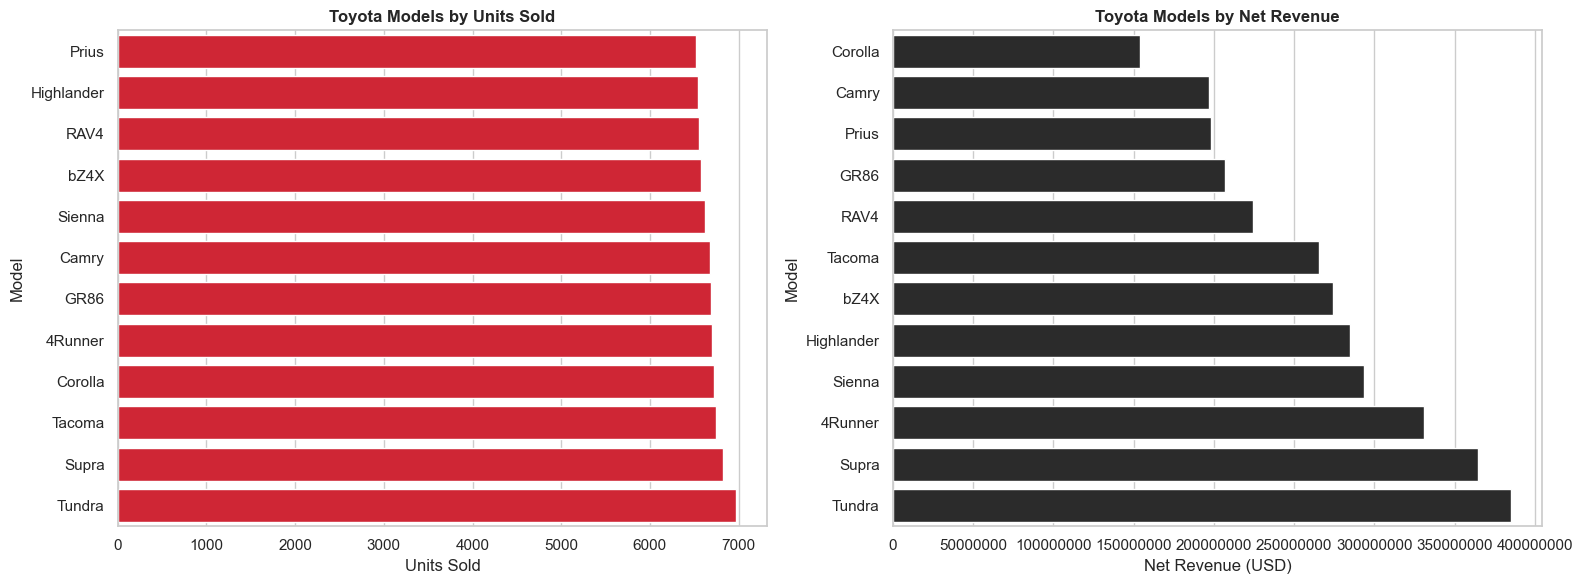

In [19]:
model_performance = (
    sales_analysis.groupby("model_name", as_index=False)
    .agg(units_sold=("quantity", "sum"), net_revenue_usd=("net_revenue_usd", "sum"))
    .sort_values("net_revenue_usd", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=model_performance.sort_values("units_sold"), x="units_sold", y="model_name", color=TOYOTA_RED, ax=axes[0])
axes[0].set(title="Toyota Models by Units Sold", xlabel="Units Sold", ylabel="Model")
sns.barplot(data=model_performance.sort_values("net_revenue_usd"), x="net_revenue_usd", y="model_name", color=CHARCOAL, ax=axes[1])
axes[1].set(title="Toyota Models by Net Revenue", xlabel="Net Revenue (USD)", ylabel="Model")
axes[1].ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()


**Interpretation:** Compare the two rankings: unit leadership and revenue leadership need not match because model price and discount mix differ.


### 5.2 How have monthly units and revenue changed over time?


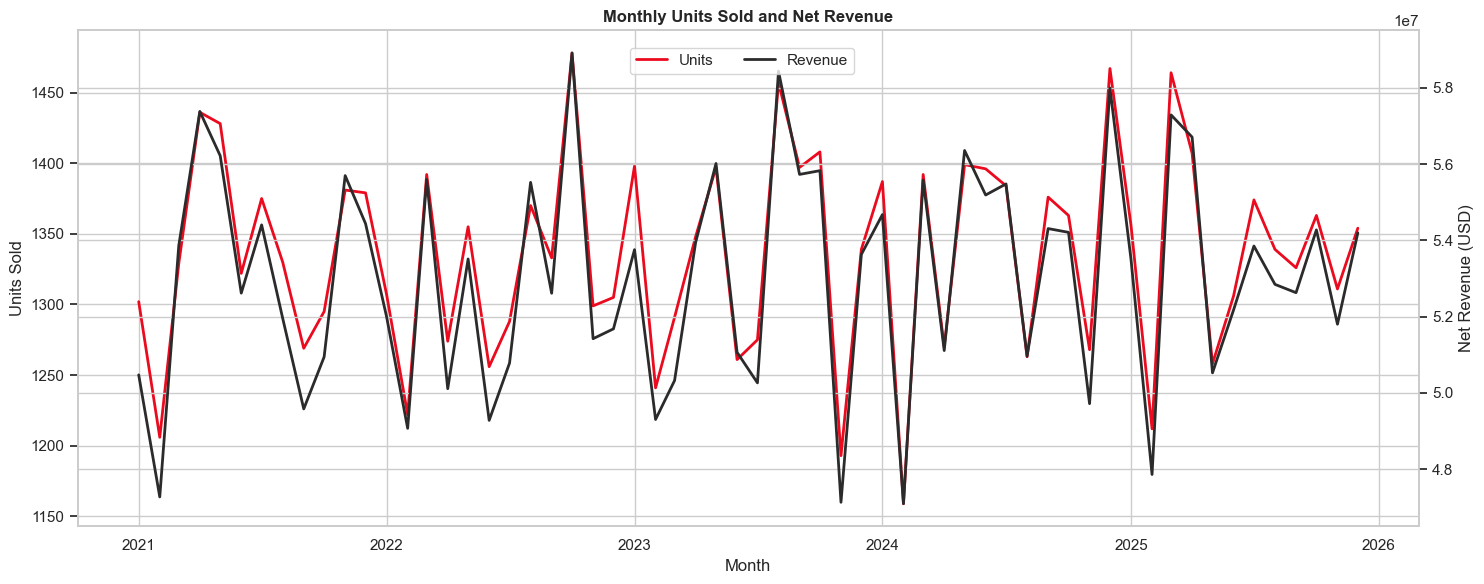

In [20]:
monthly = (
    sales_analysis.groupby("sale_month", as_index=False)
    .agg(units_sold=("quantity", "sum"), net_revenue_usd=("net_revenue_usd", "sum"))
    .sort_values("sale_month")
)

fig, ax1 = plt.subplots(figsize=(15, 6))
ax2 = ax1.twinx()
ax1.plot(monthly["sale_month"], monthly["units_sold"], color=TOYOTA_RED, linewidth=2, label="Units")
ax2.plot(monthly["sale_month"], monthly["net_revenue_usd"], color=CHARCOAL, linewidth=2, label="Revenue")
ax1.set(title="Monthly Units Sold and Net Revenue", xlabel="Month", ylabel="Units Sold")
ax2.set_ylabel("Net Revenue (USD)")
fig.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, 0.92))
plt.tight_layout()
plt.show()


**Interpretation:** The shared timeline reveals seasonality and whether revenue moves with unit volume or with changes in the price/model mix.


### 5.3 What is the fuel-type contribution to unit sales?


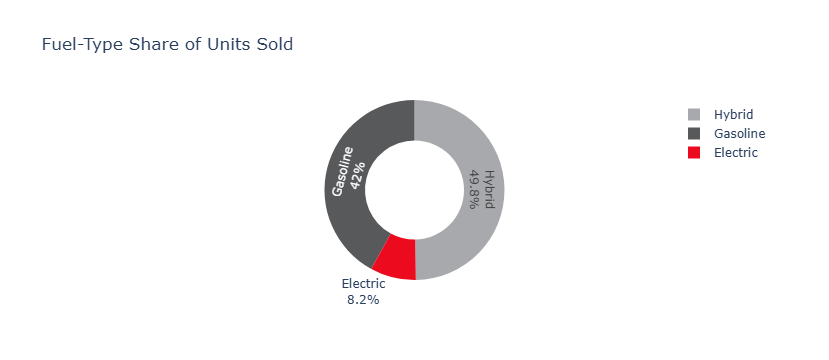

In [22]:
fuel_mix = sales_analysis.groupby("fuel_type", as_index=False)["quantity"].sum()
fig = go.Figure(
    go.Pie(
        labels=fuel_mix["fuel_type"],
        values=fuel_mix["quantity"],
        hole=0.55,
        marker_colors=PALETTE,
        textinfo="label+percent",
    )
)
fig.update_layout(title="Fuel-Type Share of Units Sold", showlegend=True)
fig.show()


**Interpretation:** This small-category view identifies the powertrain mix supported by the available `fuel_type` field. Transmission analysis is impossible because no transmission column exists.


### 5.4 How are selling prices distributed?


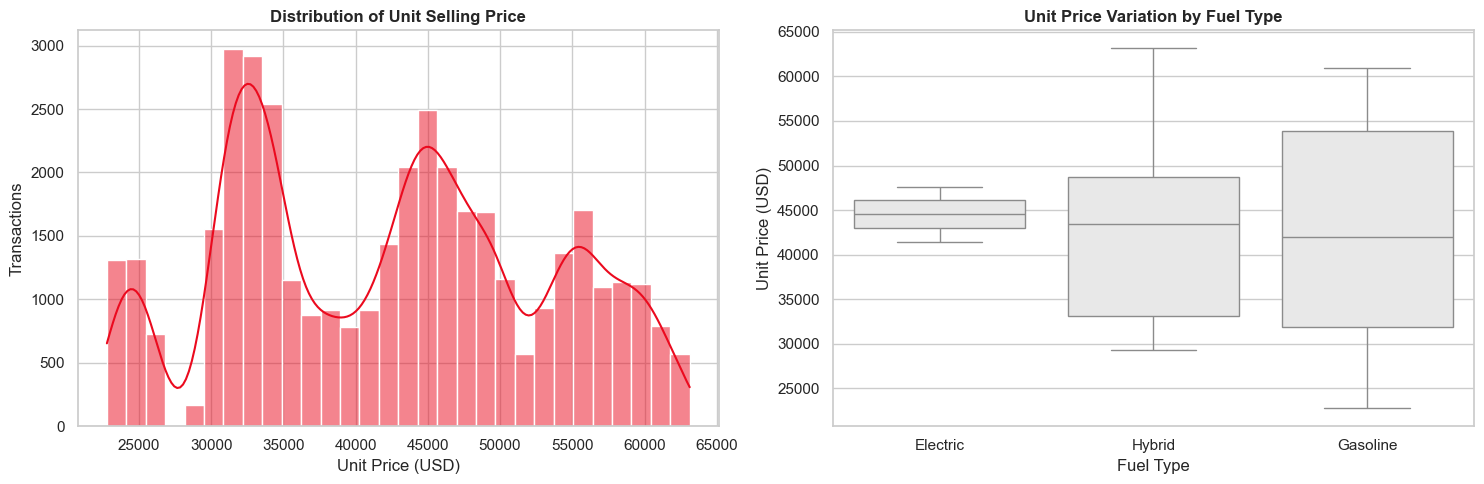

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(sales_analysis["unit_price_usd"], bins=30, kde=True, color=TOYOTA_RED, ax=axes[0])
axes[0].set(title="Distribution of Unit Selling Price", xlabel="Unit Price (USD)", ylabel="Transactions")
sns.boxplot(data=sales_analysis, x="fuel_type", y="unit_price_usd", color=LIGHT_GREY, ax=axes[1])
axes[1].set(title="Unit Price Variation by Fuel Type", xlabel="Fuel Type", ylabel="Unit Price (USD)")
plt.tight_layout()
plt.show()


**Interpretation:** The histogram shows overall price concentration; the box plot explains how powertrain mix contributes to price variation without removing valid premium transactions.


### 5.5 Is discount associated with transaction size or net revenue?


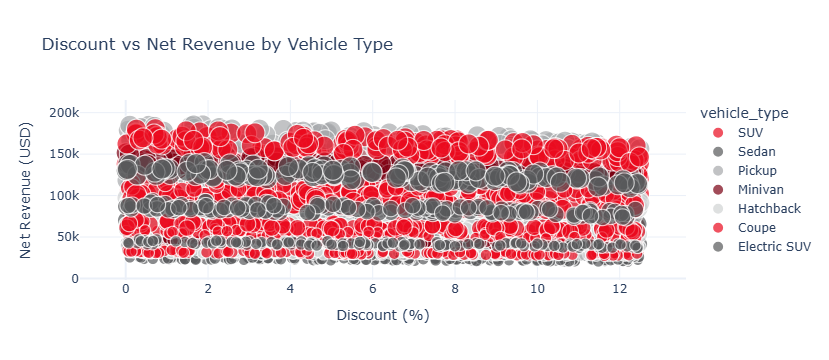

In [24]:
sample_size = min(5_000, len(sales_analysis))
plot_sample = sales_analysis.sample(sample_size, random_state=RANDOM_STATE)
fig = px.scatter(
    plot_sample,
    x="discount_pct",
    y="net_revenue_usd",
    color="vehicle_type",
    size="quantity",
    hover_data=["model_name", "region_name", "sale_date"],
    title="Discount vs Net Revenue by Vehicle Type",
    labels={"discount_pct": "Discount (%)", "net_revenue_usd": "Net Revenue (USD)"},
)
fig.show()


**Interpretation:** Bubble size separates quantity effects from discount effects. This is descriptive association, not proof that discounts cause higher sales.


### 5.6 Which numerical sales measures move together?


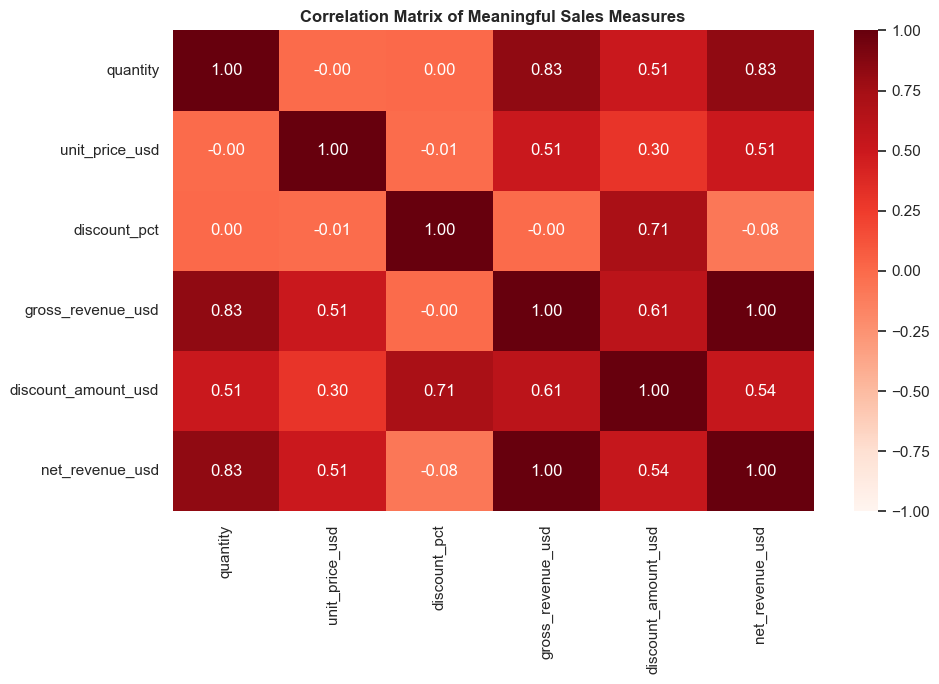

In [25]:
correlation_columns = [
    "quantity", "unit_price_usd", "discount_pct",
    "gross_revenue_usd", "discount_amount_usd", "net_revenue_usd",
]
correlation_matrix = sales_analysis[correlation_columns].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="Reds", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Meaningful Sales Measures")
plt.tight_layout()
plt.show()


**Interpretation:** Identifier codes are deliberately excluded. Revenue-derived fields will naturally correlate with their source measures and should not be interpreted as independent drivers.


### 5.7 Where is revenue concentrated across region, city, and model?


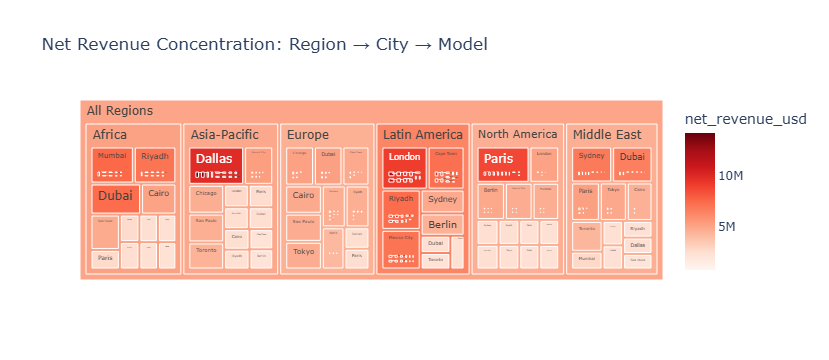

In [26]:
treemap_data = (
    sales_analysis.groupby(["region_name", "city", "model_name"], as_index=False)
    ["net_revenue_usd"].sum()
)
fig = px.treemap(
    treemap_data,
    path=[px.Constant("All Regions"), "region_name", "city", "model_name"],
    values="net_revenue_usd",
    color="net_revenue_usd",
    color_continuous_scale="Reds",
    title="Net Revenue Concentration: Region → City → Model",
)
fig.show()


**Interpretation:** Drill down from region to city and model to locate geographic/product concentration and potential over-reliance.


### 5.8 Interactive regional performance


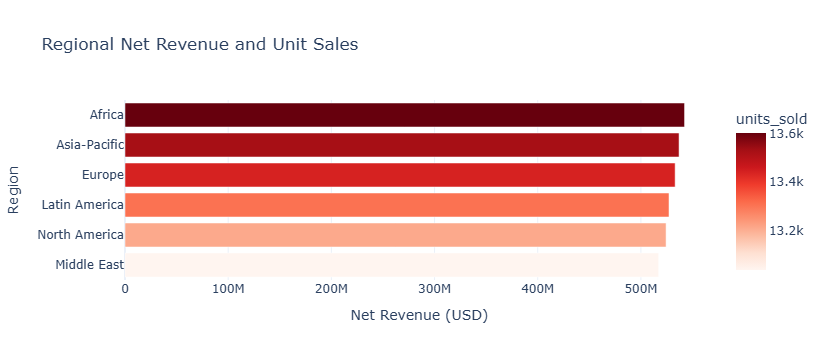

In [27]:
regional = (
    sales_analysis.groupby("region_name", as_index=False)
    .agg(units_sold=("quantity", "sum"), net_revenue_usd=("net_revenue_usd", "sum"))
    .sort_values("net_revenue_usd")
)
fig = px.bar(
    regional,
    x="net_revenue_usd",
    y="region_name",
    orientation="h",
    color="units_sold",
    color_continuous_scale="Reds",
    hover_data={"units_sold": ":,", "net_revenue_usd": ":$,.2f"},
    title="Regional Net Revenue and Unit Sales",
    labels={"net_revenue_usd": "Net Revenue (USD)", "region_name": "Region"},
)
fig.show()


**Interpretation:** Hover values allow an exact comparison of revenue and units; higher revenue can reflect either volume or a higher-value product mix.


## Phase 6 – Business KPIs

The dashboard uses USD because transaction prices are explicitly stored as `unit_price_usd`; converting to INR without a dated exchange-rate field would invent information.


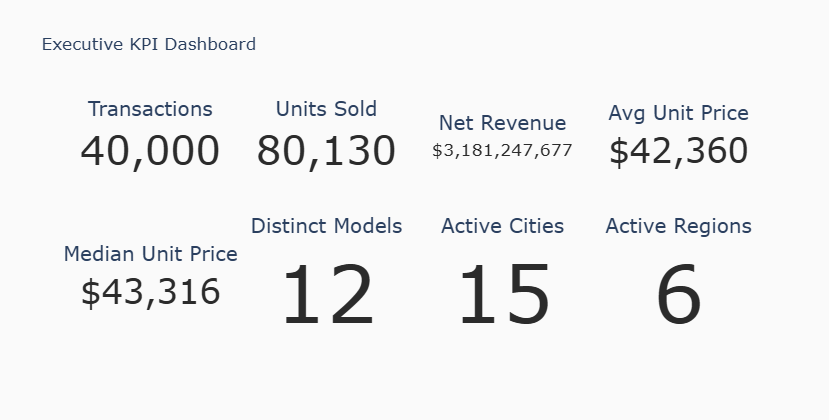

In [28]:
total_transactions = sales_analysis["sale_id"].nunique()
total_units = sales_analysis["quantity"].sum()
total_revenue = sales_analysis["net_revenue_usd"].sum()
average_unit_price = sales_analysis["unit_price_usd"].mean()
median_unit_price = sales_analysis["unit_price_usd"].median()
distinct_models = sales_analysis["model_id"].nunique()
active_cities = sales_analysis["city"].nunique()
active_regions = sales_analysis["region_name"].nunique()
average_monthly_units = monthly["units_sold"].mean()

best_selling_model = model_performance.loc[model_performance["units_sold"].idxmax(), "model_name"]
highest_revenue_model = model_performance.loc[model_performance["net_revenue_usd"].idxmax(), "model_name"]
best_city = sales_analysis.groupby("city")["net_revenue_usd"].sum().idxmax()
best_region = regional.loc[regional["net_revenue_usd"].idxmax(), "region_name"]
preferred_fuel = sales_analysis.groupby("fuel_type")["quantity"].sum().idxmax()
preferred_payment = sales_analysis.groupby("payment_method")["quantity"].sum().idxmax()

kpi_specs = [
    ("Transactions", total_transactions, ",d"),
    ("Units Sold", total_units, ",d"),
    ("Net Revenue", total_revenue, "$,.0f"),
    ("Avg Unit Price", average_unit_price, "$,.0f"),
    ("Median Unit Price", median_unit_price, "$,.0f"),
    ("Distinct Models", distinct_models, ",d"),
    ("Active Cities", active_cities, ",d"),
    ("Active Regions", active_regions, ",d"),
]

fig = go.Figure()
for index, (title, value, value_format) in enumerate(kpi_specs):
    row, column = divmod(index, 4)
    fig.add_trace(
        go.Indicator(
            mode="number",
            value=value,
            number={"valueformat": value_format, "font": {"color": CHARCOAL}},
            title={"text": title},
            domain={"row": row, "column": column},
        )
    )
fig.update_layout(
    grid={"rows": 2, "columns": 4, "pattern": "independent"},
    height=420,
    title="Executive KPI Dashboard",
    paper_bgcolor="#FAFAFA",
)
fig.show()


In [29]:
leader_summary = pd.DataFrame(
    {
        "KPI": [
            "Average monthly units", "Best-selling model", "Highest-revenue model",
            "Top city by revenue", "Top region by revenue", "Preferred fuel type",
            "Preferred payment method",
        ],
        "Result": [
            f"{average_monthly_units:,.1f}", best_selling_model,
            highest_revenue_model, best_city, best_region, preferred_fuel,
            preferred_payment,
        ],
    }
)
display(leader_summary.style.hide(axis="index"))


KPI,Result
Average monthly units,"1,335.5"
Best-selling model,Tundra
Highest-revenue model,Tundra
Top city by revenue,Dubai
Top region by revenue,Africa
Preferred fuel type,Hybrid
Preferred payment method,Cash


### Ranked performance tables


In [30]:
top_models = model_performance.assign(
    revenue_share_pct=lambda frame: frame["net_revenue_usd"].div(total_revenue).mul(100)
).head(10)

top_cities = (
    sales_analysis.groupby("city", as_index=False)
    .agg(units_sold=("quantity", "sum"), net_revenue_usd=("net_revenue_usd", "sum"))
    .sort_values("net_revenue_usd", ascending=False)
    .head(10)
)

yearly = (
    sales_analysis.groupby("sale_year", as_index=False)
    .agg(units_sold=("quantity", "sum"), net_revenue_usd=("net_revenue_usd", "sum"))
)
yearly["revenue_growth_pct"] = yearly["net_revenue_usd"].pct_change().mul(100)

display(top_models.style.format({
    "units_sold": "{:,}", "net_revenue_usd": "${:,.2f}", "revenue_share_pct": "{:.2f}%"
}).background_gradient(subset=["net_revenue_usd"], cmap="Reds"))
display(top_cities.style.format({"units_sold": "{:,}", "net_revenue_usd": "${:,.2f}"}))
display(yearly.style.format({
    "units_sold": "{:,}", "net_revenue_usd": "${:,.2f}", "revenue_growth_pct": "{:+.2f}%"
}))


,model_name,units_sold,net_revenue_usd,revenue_share_pct
10,Tundra,"6,973","$385,435,626.73",12.12%
8,Supra,"6,826","$364,846,885.69",11.47%
0,4Runner,"6,702","$330,765,337.43",10.40%
7,Sienna,"6,616","$293,866,733.35",9.24%
4,Highlander,"6,543","$285,037,814.19",8.96%
11,bZ4X,"6,571","$274,579,544.95",8.63%
9,Tacoma,"6,743","$265,368,248.13",8.34%
6,RAV4,"6,555","$224,664,066.09",7.06%
3,GR86,"6,690","$207,015,931.61",6.51%
5,Prius,"6,514","$198,491,197.60",6.24%


,city,units_sold,net_revenue_usd
5,Dubai,"7,365","$292,378,142.61"
10,Riyadh,"7,348","$291,273,246.87"
9,Paris,"6,655","$265,090,316.71"
6,London,"5,964","$238,654,896.22"
12,Sydney,"5,989","$237,407,910.14"
7,Mexico City,"5,445","$216,349,374.95"
2,Cape Town,"5,464","$216,336,207.68"
4,Dallas,"5,375","$214,279,310.93"
11,Sao Paulo,"5,282","$208,559,076.45"
8,Mumbai,"4,745","$189,771,503.35"


,sale_year,units_sold,net_revenue_usd,revenue_growth_pct
0,2021,"16,052","$634,871,399.98",+nan%
1,2022,"15,879","$630,518,545.58",-0.69%
2,2023,"16,005","$635,459,255.84",+0.78%
3,2024,"16,124","$642,708,677.34",+1.14%
4,2025,"16,070","$637,689,797.97",-0.78%


## Phase 7 – Business Insights

The following narrative is generated from calculated outputs, so the metrics remain reproducible after a database refresh.


In [31]:
model_units = model_performance.loc[model_performance["units_sold"].idxmax()]
model_revenue = model_performance.loc[model_performance["net_revenue_usd"].idxmax()]
lowest_model = model_performance.loc[model_performance["units_sold"].idxmin()]
top_region_row = regional.loc[regional["net_revenue_usd"].idxmax()]
top_month_row = monthly.loc[monthly["net_revenue_usd"].idxmax()]
top_fuel_row = fuel_mix.loc[fuel_mix["quantity"].idxmax()]
top_five_share = model_performance.head(5)["net_revenue_usd"].sum() / total_revenue * 100

insight_markdown = f'''
### 1. Product volume leader
**{model_units['model_name']}** is the best-selling model with **{model_units['units_sold']:,.0f} units**, representing **{model_units['units_sold'] / total_units:.2%}** of all units.  
**Action:** protect availability for this model and compare its regional mix before allocating incremental inventory.

### 2. Revenue leader
**{model_revenue['model_name']}** generates the highest net revenue at **${model_revenue['net_revenue_usd']:,.2f}**, or **{model_revenue['net_revenue_usd'] / total_revenue:.2%}** of total net revenue.  
**Action:** prioritise qualified leads and service retention for this high-value model while monitoring discount discipline.

### 3. Lowest unit-volume model
**{lowest_model['model_name']}** records the lowest unit volume at **{lowest_model['units_sold']:,.0f} units**.  
**Action:** diagnose performance by region and customer type before changing pricing; low volume may be expected for a niche model.

### 4. Geographic leader
**{top_region_row['region_name']}** leads regional revenue with **${top_region_row['net_revenue_usd']:,.2f}** and **{top_region_row['units_sold']:,.0f} units**.  
**Action:** identify the leading city/model combinations in the treemap and test whether their practices transfer to weaker regions.

### 5. Peak month and concentration
The strongest month is **{top_month_row['sale_month']:%B %Y}**, producing **${top_month_row['net_revenue_usd']:,.2f}** from **{top_month_row['units_sold']:,.0f} units**. The top five models contribute **{top_five_share:.2f}%** of revenue.  
**Action:** align campaign and inventory calendars to the observed peak, while monitoring concentration risk.

### 6. Fuel preference
**{top_fuel_row['fuel_type']}** leads with **{top_fuel_row['quantity']:,.0f} units**, equal to **{top_fuel_row['quantity'] / total_units:.2%}** of unit sales.  
**Action:** reflect the observed powertrain preference in local assortment planning, validated by region rather than applied uniformly.
'''
display(Markdown(insight_markdown))



### 1. Product volume leader
**Tundra** is the best-selling model with **6,973 units**, representing **8.70%** of all units.  
**Action:** protect availability for this model and compare its regional mix before allocating incremental inventory.

### 2. Revenue leader
**Tundra** generates the highest net revenue at **$385,435,626.73**, or **12.12%** of total net revenue.  
**Action:** prioritise qualified leads and service retention for this high-value model while monitoring discount discipline.

### 3. Lowest unit-volume model
**Prius** records the lowest unit volume at **6,514 units**.  
**Action:** diagnose performance by region and customer type before changing pricing; low volume may be expected for a niche model.

### 4. Geographic leader
**Africa** leads regional revenue with **$542,289,579.47** and **13,606 units**.  
**Action:** identify the leading city/model combinations in the treemap and test whether their practices transfer to weaker regions.

### 5. Peak month and concentration
The strongest month is **October 2022**, producing **$58,918,514.94** from **1,478 units**. The top five models contribute **52.18%** of revenue.  
**Action:** align campaign and inventory calendars to the observed peak, while monitoring concentration risk.

### 6. Fuel preference
**Hybrid** leads with **39,878 units**, equal to **49.77%** of unit sales.  
**Action:** reflect the observed powertrain preference in local assortment planning, validated by region rather than applied uniformly.


### Additional operational opportunities


In [32]:
inventory_view = (
    inventory.merge(cleaned_tables["models"], on="model_id", validate="many_to_one")
    .merge(cleaned_tables["dealerships"], on="dealership_id", validate="many_to_one")
    .merge(cleaned_tables["regions"][["region_id", "region_name"]], on="region_id", validate="many_to_one")
)
in_stock = inventory_view.loc[inventory_view["inventory_status"].eq("In Stock")]
inventory_summary = (
    in_stock.groupby("model_name", as_index=False)
    .agg(units_available=("units_available", "sum"))
)
inventory_value = (
    in_stock.assign(line_value_usd=lambda frame: frame["units_available"] * frame["cost_per_unit_usd"])
    .groupby("model_name", as_index=False)["line_value_usd"].sum()
)
inventory_summary = inventory_summary.merge(inventory_value, on="model_name")

service_analysis = (
    service.merge(sales[["sale_id", "model_id", "sale_date"]], on="sale_id", validate="many_to_one")
    .merge(cleaned_tables["models"][["model_id", "model_name"]], on="model_id", validate="many_to_one")
)
service_analysis["days_to_service"] = (service_analysis["service_date"] - service_analysis["sale_date"]).dt.days
service_summary = (
    service_analysis.groupby("model_name", as_index=False)
    .agg(
        service_visits=("service_id", "count"),
        avg_satisfaction=("satisfaction_score", "mean"),
        avg_days_to_service=("days_to_service", "mean"),
        service_cost_usd=("service_cost_usd", "sum"),
    )
    .sort_values("avg_satisfaction", ascending=False)
)

display(inventory_summary.sort_values("units_available", ascending=False).style.format({"line_value_usd": "${:,.2f}"}))
display(service_summary.style.format({
    "avg_satisfaction": "{:.2f}", "avg_days_to_service": "{:.1f}", "service_cost_usd": "${:,.2f}"
}))


,model_name,units_available,line_value_usd
4,Highlander,2097,"$83,377,028.00"
10,Tundra,1844,"$92,869,505.00"
1,Camry,1842,"$49,668,907.00"
0,4Runner,1830,"$82,111,089.00"
9,Tacoma,1758,"$63,076,054.00"
3,GR86,1667,"$46,953,291.00"
11,bZ4X,1638,"$62,177,577.00"
6,RAV4,1634,"$50,982,738.00"
5,Prius,1619,"$45,117,365.00"
8,Supra,1570,"$76,505,661.00"


,model_name,service_visits,avg_satisfaction,avg_days_to_service,service_cost_usd
2,Corolla,573,5.64,459.0,"$448,766.00"
5,Prius,561,5.63,443.2,"$455,162.00"
6,RAV4,602,5.55,443.4,"$476,504.00"
0,4Runner,643,5.54,440.4,"$491,999.00"
9,Tacoma,554,5.54,464.4,"$448,115.00"
4,Highlander,560,5.51,462.9,"$450,132.00"
1,Camry,534,5.47,461.2,"$412,072.00"
11,bZ4X,578,5.44,466.0,"$453,273.00"
10,Tundra,621,5.37,464.0,"$495,949.00"
8,Supra,575,5.36,454.8,"$458,779.00"


**Interpretation:** Inventory value is a point-in-time operational measure, not sales profit. Service satisfaction and time-to-service offer valid after-sales alternatives where marketing, profitability, and demographic data are unavailable.


## Conclusion

### Key Findings

This notebook builds a reproducible, transaction-level view of sales and evaluates model, time, fuel, geographic, inventory, customer, and service performance. The preceding KPI and insight cells calculate all numerical findings directly from the current MySQL data rather than hard-coding them.

### Business Recommendations

1. Protect availability for high-volume models while using revenue share to distinguish volume leaders from value leaders.
2. Allocate inventory with regional and city/model demand patterns, not a single global mix.
3. Review discount performance alongside quantity and model mix; the scatter plot shows association, not causality.
4. Plan around observed monthly peaks and track year-over-year results with the generated KPI tables.
5. Use service satisfaction and time-to-service to target after-sales improvement by model.

### Final Observations

The project demonstrates how a normalised MySQL database can support an auditable Python analytics workflow—from validation and careful feature engineering through interactive exploration and executive reporting. Because the data is synthetic, the results demonstrate analytical technique rather than actual Toyota corporate performance.

### Future Improvements

- Add transaction-level cost/COGS to calculate gross profit and margin correctly.
- Add customer demographics and consented behavioural data for responsible segmentation.
- Add campaign and channel fields for marketing attribution.
- Add inventory snapshots and stock-flow events for robust sell-through and ageing measures.
- Add local-currency values or dated exchange rates for currency conversion.
- Add transmission and vehicle manufacture-year fields for preference and vehicle-age analysis.
- Build a time-series forecast only after checking stability, leakage, and sufficient history.
- Publish a Streamlit dashboard and automate credential-safe database refreshes.


---
### Reproducibility Checklist

- Run cells from top to bottom after loading the supplied schema and data dumps into MySQL.
- Keep credentials in environment variables; never commit passwords or `.env` files.
- Install: `pandas`, `numpy`, `matplotlib`, `seaborn`, `plotly`, `sqlalchemy`, and `pymysql`.
- Analytical currency: USD, exactly as stored in the source schema.
- Random sampling uses `RANDOM_STATE = 42`.
- Re-run the notebook after each database refresh; KPI and insight text updates from calculated values.
